# Day 4-03｜人體姿態點與投籃角度分析
> Python 籃球運動資料分析課程  
> 使用 MediaPipe 讀取 `assets/converted/` 內的真實影片，計算手肘、膝蓋與肩膀角度。  
> 修課背景：具備基礎 Python 語法即可；不預設電腦視覺或運動資料分析經驗。

## 學習目標
- 理解 pose landmarks 如何整理成表格資料。
- 由關節點計算角度時間序列。
- 輸出 CSV、角度圖、骨架示意圖與動態 overlay 預覽影片。

## 完成產出
- 姿態角度 CSV、角度折線圖、骨架預覽圖與 overlay 預覽影片。

## 課堂要求
- 請先確認 `assets/converted/` 內至少有一支 mp4。
- 按照本單元順序執行各段程式。
- 完成指定輸出後，記錄結果並供課堂討論。


## 執行階段提醒
如果你是在 Google Colab 操作，請同學優先選擇 **T4 GPU**。  
這份 notebook 會先嘗試使用 MediaPipe 的 GPU delegate；若環境不支援，程式會自動退回 CPU。若執行太久，請你先把 `POSE_STRIDE` 調大，例如 `8` 或 `10`。


## 課程流程
1. 確認 `assets/converted/` 內至少有一支 converted 影片。
2. 使用 MediaPipe 讀取影片中的投籃姿態。
3. 輸出 Day 5 報告需要的姿態角度資料與 overlay 預覽影片。


In [1]:
from pathlib import Path
import subprocess
import sys

COURSE_ROOT_HINT = next(
    (p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "src" / "course_setup.py").exists()),
    Path("/content/basketball_hackathon/course"),
)
if not (COURSE_ROOT_HINT / "src" / "course_setup.py").exists() and "google.colab" in sys.modules:
    COURSE_ROOT_HINT.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run([
        "git", "clone", "--depth", "1", "https://github.com/henry753951/basketball-hackathon-course.git", str(COURSE_ROOT_HINT)
    ], check=True)
if str(COURSE_ROOT_HINT) not in sys.path:
    sys.path.insert(0, str(COURSE_ROOT_HINT))

from src.course_setup import bootstrap_course_repo  # noqa: E402

COURSE_ROOT = bootstrap_course_repo(COURSE_ROOT_HINT)


課程根目錄: H:\Repos\basketball-hackathon-course
素材資料夾: H:\Repos\basketball-hackathon-course\assets
工具模組: H:\Repos\basketball-hackathon-course\src


In [2]:
from src.video_utils import display_video_in_notebook, list_videos, pick_first_converted_video
from src.shooting_utils import draw_skeleton, render_pose_overlay_video
from src.cv_utils import show_image, save_image_rgb
from src.plot_utils import plot_angle_series

converted = list_videos(COURSE_ROOT / "assets" / "converted")
video_path = pick_first_converted_video(COURSE_ROOT)
print("converted videos:", [p.name for p in converted])
print("using video:", video_path)


converted videos: ['video_001.mp4']
using video: H:\Repos\basketball-hackathon-course\assets\converted\video_001.mp4


In [3]:
video_path

WindowsPath('H:/Repos/basketball-hackathon-course/assets/converted/video_001.mp4')

In [4]:
from src.shooting_utils import extract_pose_sequence_mediapipe_tasks

POSE_SIDE = "right"
POSE_STRIDE = 5
POSE_DELEGATE = "auto"

pose_df = extract_pose_sequence_mediapipe_tasks(
    video_path,
    course_root=COURSE_ROOT,
    stride=POSE_STRIDE,
    side=POSE_SIDE,
    delegate=POSE_DELEGATE,
)
print("rows:", len(pose_df))
pose_df.head()


Pose landmarker delegate: cpu; stride=5
rows: 224


,frame,shoulder_x,shoulder_y,elbow_x,elbow_y,wrist_x,wrist_y,hip_x,hip_y,knee_x,knee_y,ankle_x,ankle_y,elbow_angle,knee_angle,shoulder_angle
0,0,516.265945,328.305688,521.971512,344.745827,546.252556,346.013546,535.612793,377.866087,510.079231,401.218472,502.776489,441.831450,112.128095,142.638886,2.184755
1,5,511.975899,327.987878,522.003555,344.575539,545.774727,343.895030,514.871521,375.355539,505.601044,406.827164,500.720406,443.532872,119.514228,171.160812,27.655831
2,10,511.114502,329.507747,529.225464,345.006495,547.700195,339.032099,503.631516,381.740828,505.350990,414.158993,499.235229,445.836868,121.523936,166.036709,57.597011
3,15,511.692657,330.832093,534.630203,343.161371,552.617416,334.114709,501.172447,381.221724,508.715286,411.759982,499.537849,443.662176,125.041206,150.076683,73.533963
4,20,513.875427,332.679770,537.430611,344.690487,552.396431,334.538090,502.460861,381.551356,513.024826,412.506924,502.407265,443.825984,118.831222,142.429852,76.129572


saved: H:\Repos\basketball-hackathon-course\assets\results\d4_03_pose_angles.csv


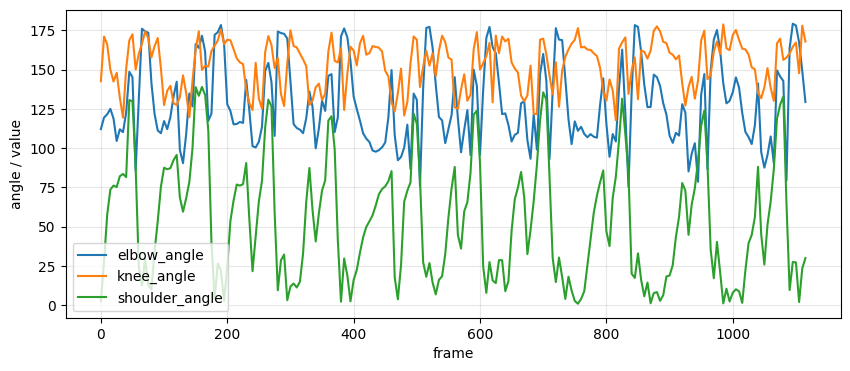

saved: H:\Repos\basketball-hackathon-course\assets\results\d4_03_pose_angle_plot.png


In [5]:
out_csv = COURSE_ROOT / "assets" / "results" / "d4_03_pose_angles.csv"
out_csv.parent.mkdir(parents=True, exist_ok=True)
angle_plot_png = COURSE_ROOT / "assets" / "results" / "d4_03_pose_angle_plot.png"

pose_df.to_csv(out_csv, index=False)
print("saved:", out_csv)

plot_angle_series(
    pose_df,
    ["elbow_angle", "knee_angle", "shoulder_angle"],
    output_path=angle_plot_png,
)
print("saved:", angle_plot_png)


In [6]:
pose_overlay_mp4 = COURSE_ROOT / "assets" / "results" / "d4_03_pose_overlay_preview.mp4"
render_pose_overlay_video(
    video_path,
    pose_df,
    pose_overlay_mp4,
    max_frames=180,
    trail_joint="wrist",
)
print("saved:", pose_overlay_mp4)
display_video_in_notebook(pose_overlay_mp4, width=720, muted=True, loop=True)


$ C:\Users\henry\scoop\apps\ffmpeg-shared\8.1\bin\ffmpeg.exe -y -i H:\Repos\basketball-hackathon-course\assets\results\d4_03_pose_overlay_preview.mp4 -an -vcodec libx264 -pix_fmt yuv420p -movflags +faststart -preset veryfast -crf 23 H:\Repos\basketball-hackathon-course\assets\results\d4_03_pose_overlay_preview.notebook.mp4
saved: H:\Repos\basketball-hackathon-course\assets\results\d4_03_pose_overlay_preview.mp4


## 本單元產出檔案

- `assets/results/d4_03_pose_angles.csv`：逐 frame 的姿態角度資料。
- `assets/results/d4_03_pose_angle_plot.png`：角度變化折線圖。
- `assets/results/d4_03_pose_overlay_preview.mp4`：把骨架與 wrist 歷史軌跡疊回原影片的預覽。
- `assets/results/d4_03_pose_skeleton_sample.png`：姿態骨架示意圖。
